<a href="https://colab.research.google.com/github/narayanpawar07092007-cell/Customer-clustering/blob/main/K_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000    

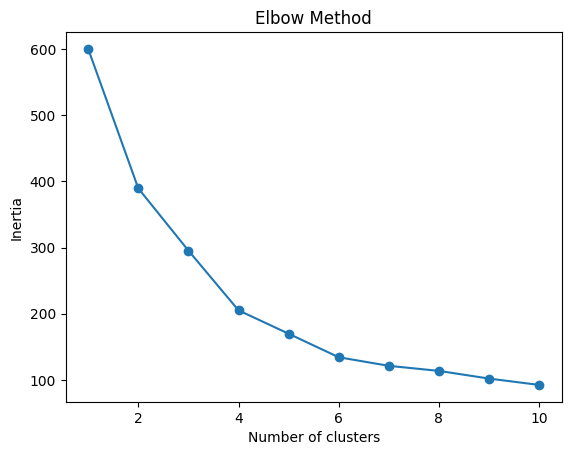

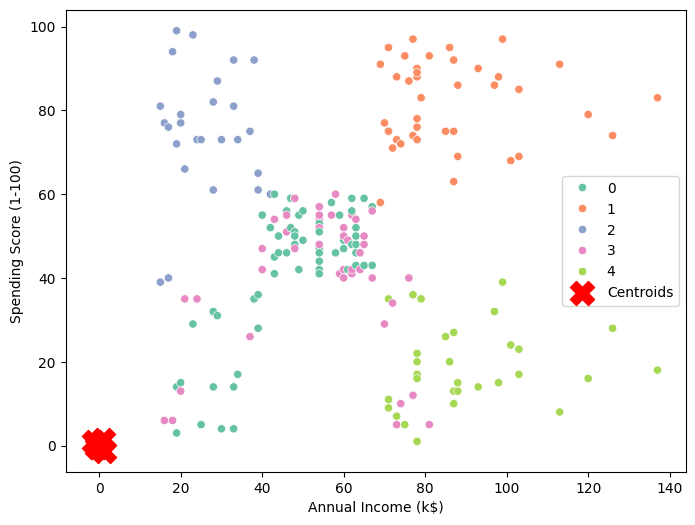


Cluster 0:
       CustomerID        Age  Annual Income (k$)  Spending Score (1-100)  \
count   58.000000  58.000000           58.000000               58.000000   
mean    68.775862  55.275862           47.620690               41.706897   
std     31.021805   8.571256           13.413567               15.697814   
min      9.000000  40.000000           19.000000                3.000000   
25%     45.500000  49.000000           39.250000               37.250000   
50%     69.500000  53.000000           48.500000               46.000000   
75%     92.500000  63.750000           59.750000               52.000000   
max    120.000000  70.000000           67.000000               60.000000   

       Cluster  
count     58.0  
mean       0.0  
std        0.0  
min        0.0  
25%        0.0  
50%        0.0  
75%        0.0  
max        0.0  

Cluster 1:
       CustomerID        Age  Annual Income (k$)  Spending Score (1-100)  \
count    40.00000  40.000000           40.000000              

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#DATA LOADING & INSPECTION

df = pd.read_csv("Mall_Customers.csv")
df.head()

print(df.info())
print(df.describe())
print(df.isnull().sum())

# FEATURE SELECTION & SCALING

df_features =df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_features)

inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

#ELBOW METHOD

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# CLUSTERING
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(data_scaled)

df.head()

# VISUALIZATION
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'],
                hue=df['Cluster'], palette='Set2')
plt.scatter(kmeans.cluster_centers_[:,1], kmeans.cluster_centers_[:,2],
            s=300, c='red', marker='X', label='Centroids')
plt.legend()
plt.show()

# CLUSTER INSIGHTS
for cluster in sorted(df['Cluster'].unique()):
    print(f"\nCluster {cluster}:")
    print(df[df['Cluster']==cluster].describe())